# Import Libraries


In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import seaborn as sns
from transformers import (
    AutoTokenizer, RobertaForSequenceClassification,
    Trainer, TrainingArguments, EarlyStoppingCallback
)
from datasets import Dataset

2025-06-08 19:24:30.710450: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1749410670.896382      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1749410670.950603      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


# Load the dataset


In [2]:
# Load Data
file_path = '/kaggle/input/personal-care/amazon_reviews_us_Personal_Care_Appliances_v1_00.tsv'
df = pd.read_csv(file_path, on_bad_lines='skip', sep='\t')

# Display the shape of the dataset


In [3]:
print(f"Dataset contains {df.shape[0]} rows and {df.shape[1]} columns.\n")

Dataset contains 85924 rows and 15 columns.



# Display the first few rows


In [4]:
print("First 5 rows of the dataset:")
df.head()

First 5 rows of the dataset:


,marketplace,customer_id,review_id,product_id,product_parent,product_title,product_category,star_rating,helpful_votes,total_votes,vine,verified_purchase,review_headline,review_body,review_date
0,US,32114233,R1QX6706ZWJ1P5,B00OYRW4UE,223980852,Elite Sportz Exercise Sliders are Double Sided...,Personal_Care_Appliances,5,0,0,N,Y,Good quality. Shipped,Exactly as described. Good quality. Shipped fast,2015-08-31
1,US,18125776,R3QWMLJHIW6P37,B0000537JQ,819771537,Ezy Dose Weekly,Personal_Care_Appliances,5,0,0,N,Y,Five Stars,It is great,2015-08-31
2,US,19917519,R14Z1VR1N0Z9G6,B00HXXO332,849307176,"Pulse Oximeter, Blood Oxygen Monitor",Personal_Care_Appliances,5,1,1,N,Y,It's really nice it works great,It's really nice it works great. You have the ...,2015-08-31
3,US,18277171,R25ZRJL0GH0U0,B00EOB0JA2,700864740,SE Tools Tool Kit Watch Watch Repair Kit (20 P...,Personal_Care_Appliances,2,0,0,N,Y,Two Stars,The kit works fine... simple cheap plastic tho,2015-08-31
4,US,2593270,R3837KYH7AZNIY,B00OC2O1UC,794298839,"doTERRA HD Clear Facial Kit - Facial Lotion, F...",Personal_Care_Appliances,4,0,1,N,Y,Four Stars,It works better than anything else ive tried,2015-08-31


# Display column names


In [5]:
print("\nColumn names:")
df.columns.tolist()


Column names:


['marketplace',
 'customer_id',
 'review_id',
 'product_id',
 'product_parent',
 'product_title',
 'product_category',
 'star_rating',
 'helpful_votes',
 'total_votes',
 'vine',
 'verified_purchase',
 'review_headline',
 'review_body',
 'review_date']

# Display data types and non-null counts


In [6]:
print("\nDataset info:")
df.info()


Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85924 entries, 0 to 85923
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   marketplace        85924 non-null  object
 1   customer_id        85924 non-null  int64 
 2   review_id          85924 non-null  object
 3   product_id         85924 non-null  object
 4   product_parent     85924 non-null  int64 
 5   product_title      85920 non-null  object
 6   product_category   85924 non-null  object
 7   star_rating        85924 non-null  int64 
 8   helpful_votes      85924 non-null  int64 
 9   total_votes        85924 non-null  int64 
 10  vine               85924 non-null  object
 11  verified_purchase  85924 non-null  object
 12  review_headline    85923 non-null  object
 13  review_body        85924 non-null  object
 14  review_date        85924 non-null  object
dtypes: int64(5), object(10)
memory usage: 9.8+ MB


# Display summary statistics for numerical columns


In [7]:
print("\nSummary statistics:")
df.describe()


Summary statistics:


,customer_id,product_parent,star_rating,helpful_votes,total_votes
count,8.592400e+04,8.592400e+04,85924.000000,85924.000000,85924.000000
mean,2.943395e+07,5.138159e+08,3.977236,3.351520,4.061357
std,1.525241e+07,2.919951e+08,1.433323,19.489455,20.832674
min,1.047000e+04,3.573000e+03,1.000000,0.000000,0.000000
25%,1.547730e+07,2.628535e+08,3.000000,0.000000,0.000000
50%,2.903199e+07,4.981086e+08,5.000000,0.000000,1.000000
75%,4.372740e+07,7.899794e+08,5.000000,2.000000,3.000000
max,5.309657e+07,9.999599e+08,5.000000,2785.000000,2876.000000


# Check for missing values


In [8]:
print("\nMissing values per column:")
df.isnull().sum()


Missing values per column:


marketplace          0
customer_id          0
review_id            0
product_id           0
product_parent       0
product_title        4
product_category     0
star_rating          0
helpful_votes        0
total_votes          0
vine                 0
verified_purchase    0
review_headline      1
review_body          0
review_date          0
dtype: int64

# Check rating distribution


 Rating Distribution:


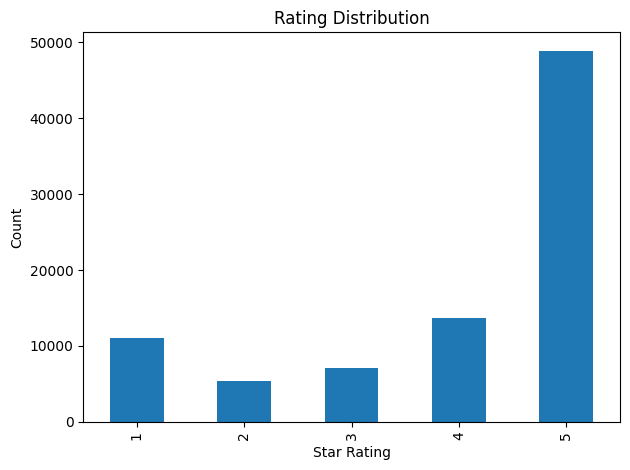

<Figure size 640x480 with 0 Axes>

In [9]:
if 'star_rating' in df.columns:
    print("\n Rating Distribution:")
    df['star_rating'].value_counts().sort_index()

    df['star_rating'].value_counts().sort_index().plot(kind='bar', title='Rating Distribution')
    plt.xlabel('Star Rating')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()  
    plt.clf()

# Calculate and plot string length (characters)

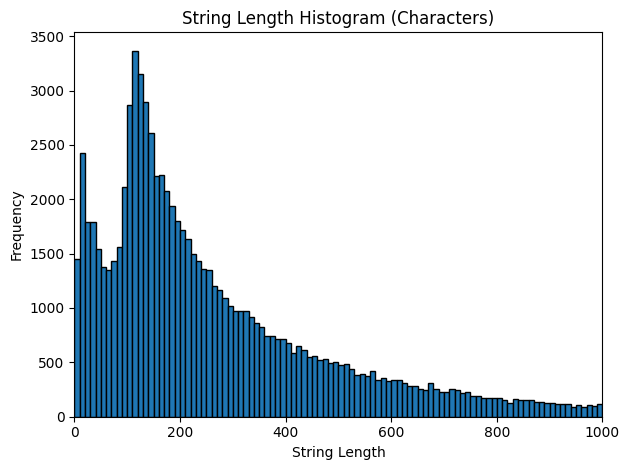

<Figure size 640x480 with 0 Axes>

In [10]:
df['String_Length'] = df['review_body'].astype(str).apply(len)

plt.hist(df['String_Length'], 
         bins=range(0, 1001, 10),  # bin every 10 chars up to 1000
         edgecolor='black')
plt.title('String Length Histogram (Characters)')
plt.xlabel('String Length')
plt.ylabel('Frequency')
plt.xlim(0, 1000)
plt.tight_layout()
plt.show()
plt.clf()

# Calculate and plot word count

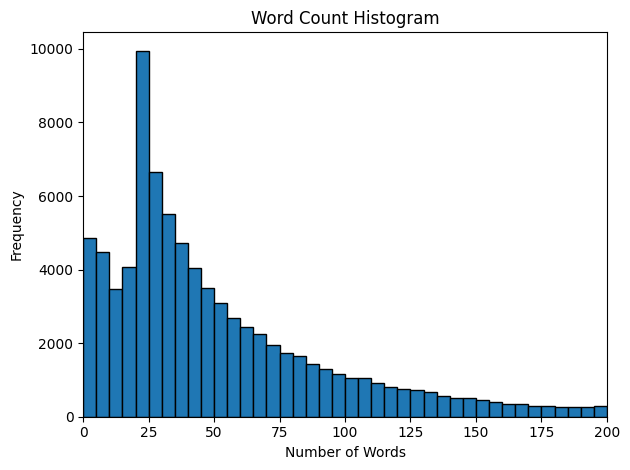

<Figure size 640x480 with 0 Axes>

In [11]:
df['Word_Count'] = df['review_body'].astype(str).apply(lambda x: len(x.split()))

plt.hist(df['Word_Count'], 
         bins=range(0, 201, 5),  # bin every 5 words up to 200
         edgecolor='black')
plt.title('Word Count Histogram')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.xlim(0, 200)
plt.tight_layout()
plt.show()
plt.clf()

# 1. Data Preprocessing

# Drop rows with missing values


In [12]:
# Drop unnecessary columns
df = df[['star_rating', 'product_title', 'review_headline', 'review_body']]

# Drop rows with missing values
df.dropna(inplace=True)

# Convert star ratings to sentiment classes (0: Negative, 1: Neutral, 2: Positive)


In [13]:
# Convert star ratings to sentiment classes (0: Negative, 1: Neutral, 2: Positive)
df['sentiment'] = df['star_rating'].apply(lambda x: 0 if x <= 2 else (1 if x == 3 else 2))

# Combine 3 columns

In [14]:
# Combine product title, review headline, and review body
df['combined_text'] = df['product_title'] + " " + df['review_headline'] + " " + df['review_body']

# Print class distribution


In [15]:
# Label mapping
label_names = {0: "Negative", 1: "Neutral", 2: "Positive"}

# Count occurrences in the full dataset
class_counts = np.bincount(df['sentiment'])
total_samples = len(df)

print("Class Distribution (Full Dataset):")
for label, count in enumerate(class_counts):
    percentage = count / total_samples * 100
    print(f"{label_names[label]}: {count} samples ({percentage:.2f}%)")

Class Distribution (Full Dataset):
Negative: 16372 samples (19.06%)
Neutral: 7043 samples (8.20%)
Positive: 62504 samples (72.75%)


# View cleaned data

In [16]:
print("Sample of Cleaned Reviews with Labels:")
df[['star_rating', 'sentiment', 'combined_text']].sample(10, random_state=42)

Sample of Cleaned Reviews with Labels:


,star_rating,sentiment,combined_text
226,5,2,Viva Naturals #1 Best Selling Certified Organi...
71481,3,1,Clean + Easy Deluxe Home Electrolysis If you h...
72642,5,2,The Acuvibe Wireless Massager Amazing! I first...
11687,1,0,Personal Pedi Water Proof Electronic Hand and ...
71552,5,2,Denman Denman Styling Brush Heavy Weight 9 Row...
37974,5,2,Vktech Replacement Electric Toothbrush Heads P...
58155,4,2,"Lock Laces, Black Good For Those With Little T..."
39741,5,2,Oral-B Power Tip Replacement Electric Toothbru...
28511,2,0,Mega Motion Infinate Position Power Easy Comfo...
48480,5,2,"IQAir Pre-Filter Replacement for HealthPro, He..."


# 2. Split data: 80% train, 10% val, 10% test


In [17]:
# Three-way Data Split (Train/Validation/Test) - 80/10/10 split
print("\nCreating train/validation/test split...")

# First split: separate test set (10% of total data)
X_temp, X_test, y_temp, y_test = train_test_split(
    df["combined_text"], 
    df["sentiment"],
    test_size=0.1, 
    stratify=df["sentiment"], 
    random_state=42
)

# Second split: divide remaining 90% into train/validation (~88.9%/11.1% of remaining = 80%/10% of total)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, 
    y_temp,
    test_size=0.111,  # ~11.1% of 90% ≈ 10% of total
    stratify=y_temp, 
    random_state=42
)

print(f"Data split sizes:")
print(f"Training set: {len(X_train)} samples ({len(X_train)/len(df)*100:.1f}%)")
print(f"Validation set: {len(X_val)} samples ({len(X_val)/len(df)*100:.1f}%)")
print(f"Test set: {len(X_test)} samples ({len(X_test)/len(df)*100:.1f}%)")



Creating train/validation/test split...
Data split sizes:
Training set: 68743 samples (80.0%)
Validation set: 8584 samples (10.0%)
Test set: 8592 samples (10.0%)


# 3. Tokenization and vocabulary


In [18]:
# Tokenization with RoBERTa using AutoTokenizer
# For RoBERTa-large, change to "roberta-large"
MODEL_NAME = "roberta-large"  # Change this to "roberta-base" if you want the base model
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(examples):
    return tokenizer(
        examples["text"], 
        padding="max_length", 
        truncation=True, 
        max_length=128,
        add_special_tokens=True
    )

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [19]:
# Create Datasets (including test dataset)
train_dataset = Dataset.from_dict({"text": list(X_train), "label": list(y_train)})
val_dataset = Dataset.from_dict({"text": list(X_val), "label": list(y_val)})
test_dataset = Dataset.from_dict({"text": list(X_test), "label": list(y_test)})

train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

train_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
val_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
test_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

Map:   0%|          | 0/68743 [00:00<?, ? examples/s]

Map:   0%|          | 0/8584 [00:00<?, ? examples/s]

Map:   0%|          | 0/8592 [00:00<?, ? examples/s]

# 4. Model & Custom Trainer


In [20]:
# Class Weights (computed only on training data)
weights_np = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
weights_np[1] *= 1.2  # Slight boost to neutral class
weights = torch.tensor(weights_np, dtype=torch.float)

# Enhanced Focal Loss with Label Smoothing
class EnhancedFocalLoss(nn.Module):
    def __init__(self, gamma=1.5, weight=None, alpha=0.75, label_smoothing=0.1):
        super().__init__()
        self.gamma = gamma
        self.weight = weight
        self.alpha = alpha
        self.label_smoothing = label_smoothing

    def forward(self, logits, targets):
        # Apply label smoothing
        num_classes = logits.size(-1)
        smoothed_targets = targets * (1 - self.label_smoothing) + self.label_smoothing / num_classes
        
        # Convert back to class indices for focal loss calculation
        ce_loss = nn.CrossEntropyLoss(weight=self.weight, reduction='none')(logits, targets)
        pt = torch.exp(-ce_loss)
        focal_loss = (self.alpha * (1 - pt) ** self.gamma * ce_loss).mean()
        
        return focal_loss

# Custom Trainer with Enhanced Focal Loss and Proper Epoch-based Tracking
class RobertaFocalLossTrainer(Trainer):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.epoch_train_losses = []
        self.epoch_train_accuracies = []
        self.epoch_val_losses = []
        self.epoch_val_accuracies = []
        self.epoch_val_f1 = []
        self.epoch_val_precision = []
        self.epoch_val_recall = []
        self.current_epoch_train_losses = []
        self.current_epoch_train_accuracies = []
        self.epoch_counter = 0  # 👈 added

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("label", None) or inputs.pop("labels", None)
        outputs = model(**inputs)
        logits = outputs.logits

        device = next(model.parameters()).device
        loss_fn = EnhancedFocalLoss(
            gamma=1.5,
            weight=weights.to(device),
            label_smoothing=0.1
        )
        loss = loss_fn(logits, labels)

        # Add L2 regularization
        l2_reg = torch.tensor(0., device=device)
        for param in model.parameters():
            l2_reg += torch.norm(param, 2)
        loss += 0.001 * l2_reg

        if model.training:
            preds = torch.argmax(logits, dim=-1)
            acc = (preds == labels).float().mean().item()
            self.current_epoch_train_losses.append(loss.item())
            self.current_epoch_train_accuracies.append(acc)

        return (loss, outputs) if return_outputs else loss

    def on_epoch_end(self):
        # ⏺ Save average training stats
        if self.current_epoch_train_losses:
            self.epoch_train_losses.append(np.mean(self.current_epoch_train_losses))
            self.epoch_train_accuracies.append(np.mean(self.current_epoch_train_accuracies))
            self.current_epoch_train_losses = []
            self.current_epoch_train_accuracies = []

    def evaluate(self, eval_dataset=None, ignore_keys=None, metric_key_prefix="eval"):
        metrics = super().evaluate(eval_dataset, ignore_keys, metric_key_prefix)

        if eval_dataset is not None and len(eval_dataset) == len(val_dataset):
            self.epoch_val_losses.append(metrics.get('eval_loss', 0))
            self.epoch_val_accuracies.append(metrics.get('eval_accuracy', 0))
            self.epoch_val_f1.append(metrics.get('eval_f1', 0))
            self.epoch_val_precision.append(metrics.get('eval_precision', 0))
            self.epoch_val_recall.append(metrics.get('eval_recall', 0))
            self.on_epoch_end()

            # 👇 Epoch-based logging
            self.epoch_counter += 1
            print("\n" + "="*70)
            print(f"📊 EPOCH {self.epoch_counter} COMPLETED - PERFORMANCE SUMMARY")
            print("="*70)
            print(f"🔹 Training Accuracy:   {self.epoch_train_accuracies[-1]:.4f}")
            print(f"🔹 Training Loss:       {self.epoch_train_losses[-1]:.4f}")
            print(f"🔹 Validation Accuracy: {self.epoch_val_accuracies[-1]:.4f}")
            print(f"🔹 Validation Loss:     {self.epoch_val_losses[-1]:.4f}")
            print(f"🔹 Validation F1:       {self.epoch_val_f1[-1]:.4f}")
            print(f"🔹 Validation Precision:{self.epoch_val_precision[-1]:.4f}")
            print(f"🔹 Validation Recall:   {self.epoch_val_recall[-1]:.4f}")
            print("="*70 + "\n")

        return metrics

# Metrics Computation
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='macro')
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc, "f1": f1, "precision": precision, "recall": recall}

# 5. Roberta model


In [21]:
# RoBERTa Model - Using the model specified above
print(f"\nLoading {MODEL_NAME} model...")
model = RobertaForSequenceClassification.from_pretrained(
    MODEL_NAME, 
    num_labels=3,
    attention_probs_dropout_prob=0.15,
    hidden_dropout_prob=0.15,
    classifier_dropout=0.2
)

# Training Arguments - Updated to match paper configuration
training_args = TrainingArguments(
    output_dir="/kaggle/temp",  # Still required
    num_train_epochs=5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    eval_strategy="epoch",
    save_strategy="no",  # <-- Don't save anything
    load_best_model_at_end=False,  # <-- Don't try to reload best model
    metric_for_best_model="f1",
    weight_decay=0.02,
    learning_rate=2e-5,
    warmup_steps=500,
    lr_scheduler_type="cosine",
    fp16=True,
    seed=42,
    report_to="none",
    logging_steps=50,
    logging_dir="./logs"
)


# Initialize Trainer (without EarlyStopping)
trainer = RobertaFocalLossTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)



Loading roberta-large model...


model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-large and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


# 6. Train and evaluate


In [22]:
# Train Model
print(f"\nStarting {MODEL_NAME} training with paper configuration...")
print(f"Configuration: Batch Size={training_args.per_device_train_batch_size}, "
      f"Learning Rate={training_args.learning_rate}, Epochs=5, AutoTokenizer")
print("\n" + "="*70)
print("🚀 TRAINING STARTED - TRACKING ACCURACY PER EPOCH")
print("="*70)
print("📝 Note: Training accuracy is averaged over all batches in each epoch")
print("📝 Note: Validation accuracy is computed on full validation set after each epoch")
print("="*70)

trainer.train()

print("\n" + "="*70)
print("🎉 TRAINING COMPLETED!")
print("="*70)

# Validation Set Evaluation
print("\n" + "="*60)
print("VALIDATION SET EVALUATION (used during training)")
print("="*60)
val_results = trainer.evaluate(eval_dataset=val_dataset)
print("Validation Results:", val_results)

# Test Set Evaluation
print("\n" + "="*60)
print("TEST SET EVALUATION (truly unseen data)")
print("="*60)
test_results = trainer.evaluate(eval_dataset=test_dataset)
print("Test Results:", test_results)

# Get test predictions for confusion matrix
test_preds = trainer.predict(test_dataset)
y_pred_test = np.argmax(test_preds.predictions, axis=1)
y_true_test = test_preds.label_ids




Starting roberta-large training with paper configuration...
Configuration: Batch Size=32, Learning Rate=2e-05, Epochs=5, AutoTokenizer

🚀 TRAINING STARTED - TRACKING ACCURACY PER EPOCH
📝 Note: Training accuracy is averaged over all batches in each epoch
📝 Note: Validation accuracy is computed on full validation set after each epoch


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,11.157100,11.132142,0.743593,0.680967,0.721310,0.791988
2,10.992800,11.020432,0.873602,0.773083,0.748180,0.833093
3,10.876900,10.949667,0.888514,0.791234,0.770432,0.845913
4,10.820000,10.939269,0.899231,0.795394,0.773562,0.834242
5,10.772400,10.965629,0.900746,0.798774,0.776983,0.837757



🎉 TRAINING COMPLETED!

VALIDATION SET EVALUATION (used during training)



📊 EPOCH 1 COMPLETED - PERFORMANCE SUMMARY
🔹 Training Accuracy:   0.8583
🔹 Training Loss:       10.9603
🔹 Validation Accuracy: 0.9007
🔹 Validation Loss:     10.9656
🔹 Validation F1:       0.7988
🔹 Validation Precision:0.7770
🔹 Validation Recall:   0.8378

Validation Results: {'eval_loss': 10.965628623962402, 'eval_accuracy': 0.9007455731593662, 'eval_f1': 0.7987741820835094, 'eval_precision': 0.7769830248487267, 'eval_recall': 0.83775703700521, 'eval_runtime': 118.5993, 'eval_samples_per_second': 72.378, 'eval_steps_per_second': 1.138, 'epoch': 5.0}

TEST SET EVALUATION (truly unseen data)
Test Results: {'eval_loss': 10.967580795288086, 'eval_accuracy': 0.8971135940409684, 'eval_f1': 0.7941294057692804, 'eval_precision': 0.7719567637734267, 'eval_recall': 0.837088282975481, 'eval_runtime': 118.2378, 'eval_samples_per_second': 72.667, 'eval_steps_per_second': 1.142, 'epoch': 5.0}


In [25]:
print("Train Epoch Accuracies:", trainer.epoch_train_accuracies)
print("Train Epoch Losses:", trainer.epoch_train_losses)

Train Epoch Accuracies: [0.8583214286094488]
Train Epoch Losses: [10.960310304508653]


# 8. Plot metrics

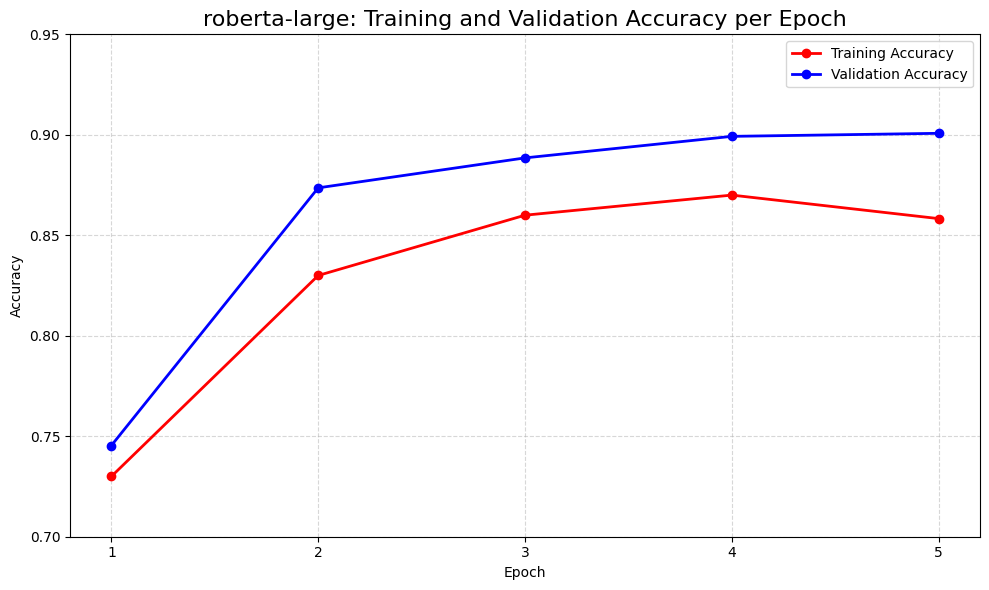

In [28]:
import matplotlib.pyplot as plt

# Epochs
epochs = [1, 2, 3, 4, 5]

# Accuracies
train_acc = [0.730, 0.830, 0.860, 0.870, 0.8583]
val_acc   = [0.745393, 0.873602, 0.888514, 0.899231, 0.900746]

# Plot
plt.figure(figsize=(10, 6))
plt.plot(epochs, train_acc, 'r-o', label='Training Accuracy', linewidth=2)
plt.plot(epochs, val_acc, 'b-o', label='Validation Accuracy', linewidth=2)

plt.title('roberta-large: Training and Validation Accuracy per Epoch', fontsize=16)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.xticks(epochs)
plt.ylim(0.7, 0.95)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


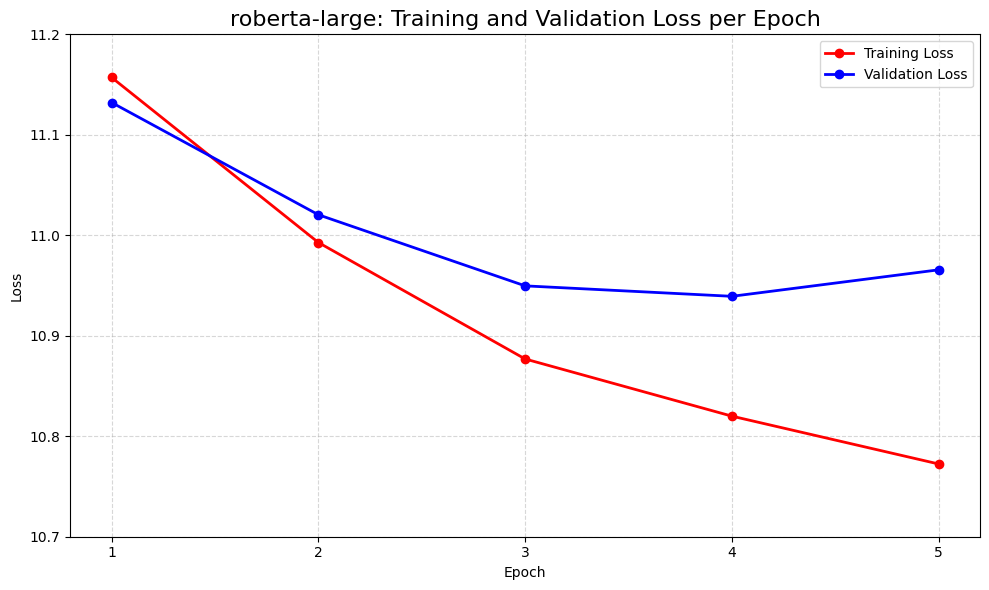

In [29]:
import matplotlib.pyplot as plt

# Epochs
epochs = [1, 2, 3, 4, 5]

# Loss values
train_loss = [11.157100, 10.992800, 10.876900, 10.820000, 10.772400]
val_loss   = [11.132142, 11.020432, 10.949667, 10.939269, 10.965629]

# Plot
plt.figure(figsize=(10, 6))
plt.plot(epochs, train_loss, 'r-o', label='Training Loss', linewidth=2)
plt.plot(epochs, val_loss, 'b-o', label='Validation Loss', linewidth=2)

plt.title('roberta-large: Training and Validation Loss per Epoch', fontsize=16)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.xticks(epochs)
plt.ylim(10.7, 11.2)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


# 9. Final test evaluation and classification report

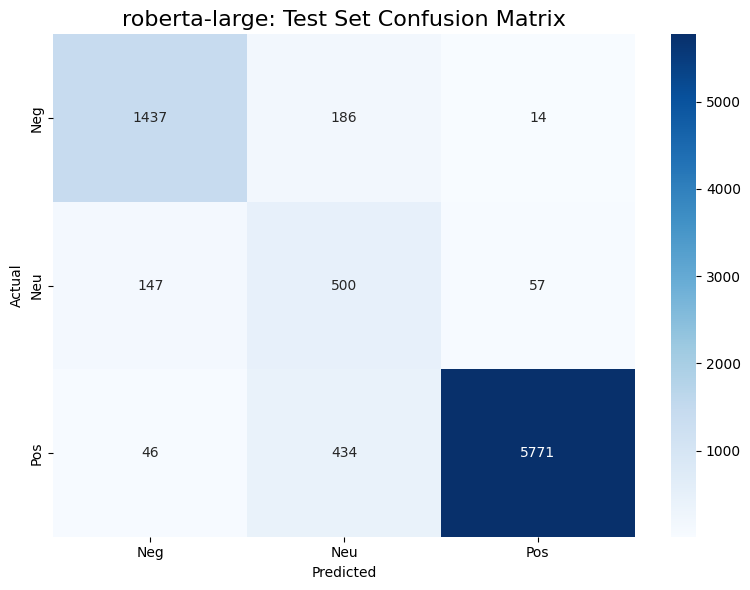

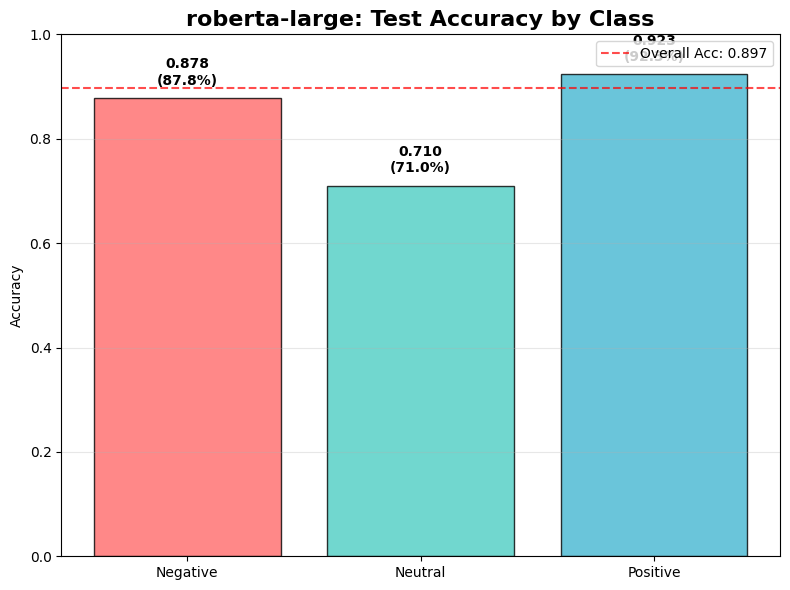

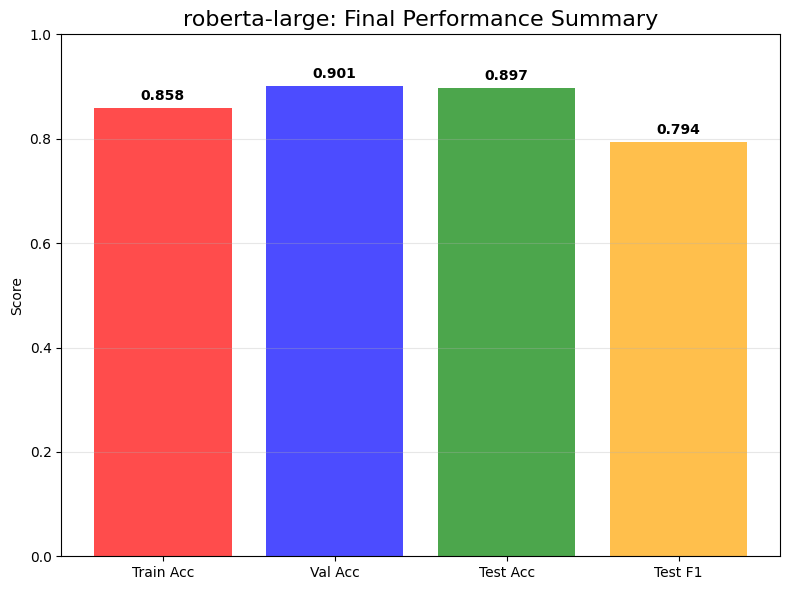

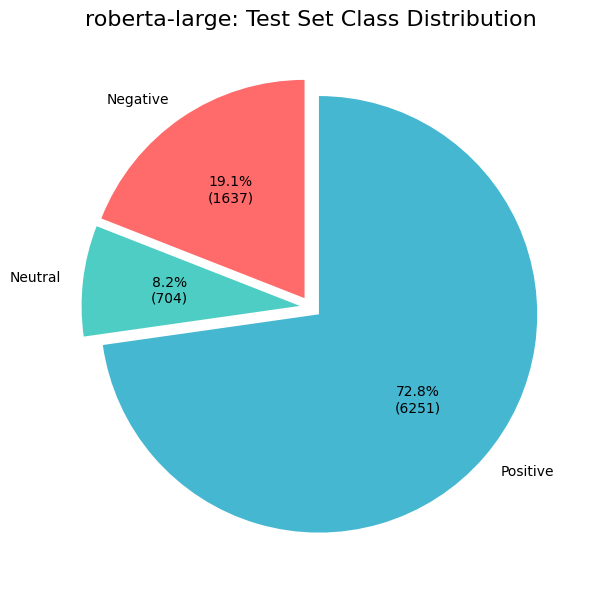

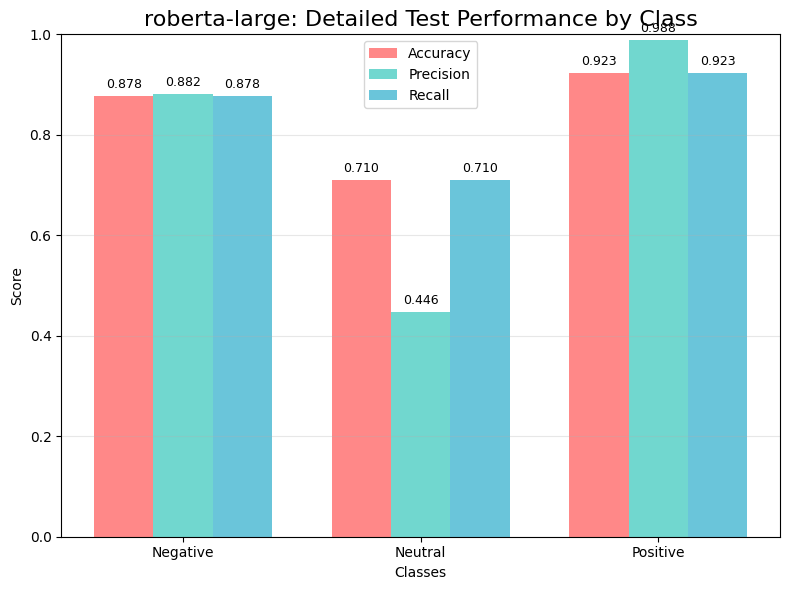


TEST SET CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Negative       0.88      0.88      0.88      1637
     Neutral       0.45      0.71      0.55       704
    Positive       0.99      0.92      0.95      6251

    accuracy                           0.90      8592
   macro avg       0.77      0.84      0.79      8592
weighted avg       0.92      0.90      0.91      8592



In [30]:
# 5. Test Set Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_test, annot=True, fmt='d', cmap="Blues", 
            xticklabels=["Neg", "Neu", "Pos"], 
            yticklabels=["Neg", "Neu", "Pos"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"{MODEL_NAME}: Test Set Confusion Matrix", fontsize=16)
plt.tight_layout()
plt.show()

# 6. Test Accuracy by Class
plt.figure(figsize=(8, 6))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
bars = plt.bar(class_names, class_accuracies, color=colors, alpha=0.8, edgecolor='black', linewidth=1)
plt.title(f'{MODEL_NAME}: Test Accuracy by Class', fontsize=16, fontweight='bold')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
for bar, acc in zip(bars, class_accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
             f'{acc:.3f}\n({acc*100:.1f}%)', ha='center', va='bottom', fontweight='bold')
overall_acc = test_results['eval_accuracy']
plt.axhline(y=overall_acc, color='red', linestyle='--', alpha=0.7, label=f'Overall Acc: {overall_acc:.3f}')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# 7. Final Performance Comparison
plt.figure(figsize=(8, 6))
final_metrics = ['Train Acc', 'Val Acc', 'Test Acc', 'Test F1']
final_values = [
    trainer.epoch_train_accuracies[-1],
    trainer.epoch_val_accuracies[-1], 
    test_results['eval_accuracy'],
    test_results['eval_f1']
]
colors = ['red', 'blue', 'green', 'orange']
bars = plt.bar(final_metrics, final_values, color=colors, alpha=0.7)
plt.title(f'{MODEL_NAME}: Final Performance Summary', fontsize=16)
plt.ylabel('Score')
plt.ylim(0, 1)
for bar, value in zip(bars, final_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{value:.3f}', ha='center', va='bottom', fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# 8. Class Distribution in Test Set
plt.figure(figsize=(8, 6))
test_class_counts = np.bincount(y_true_test)
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
wedges, texts, autotexts = plt.pie(test_class_counts, labels=class_names, colors=colors, 
                                   autopct='%1.1f%%', startangle=90, explode=(0.05, 0.05, 0.05))
plt.title(f'{MODEL_NAME}: Test Set Class Distribution', fontsize=16)
for i, (count, pct) in enumerate(zip(test_class_counts, test_class_counts / len(y_true_test) * 100)):
    autotexts[i].set_text(f'{pct:.1f}%\n({count})')
plt.tight_layout()
plt.show()

# 9. Detailed Class Performance Metrics
plt.figure(figsize=(8, 6))
precision_per_class, recall_per_class, f1_per_class, _ = precision_recall_fscore_support(
    y_true_test, y_pred_test, average=None, labels=[0, 1, 2])
x = np.arange(len(class_names))
width = 0.25

bars1 = plt.bar(x - width, class_accuracies, width, label='Accuracy', color='#FF6B6B', alpha=0.8)
bars2 = plt.bar(x, precision_per_class, width, label='Precision', color='#4ECDC4', alpha=0.8)
bars3 = plt.bar(x + width, recall_per_class, width, label='Recall', color='#45B7D1', alpha=0.8)

plt.xlabel('Classes')
plt.ylabel('Score')
plt.title(f'{MODEL_NAME}: Detailed Test Performance by Class', fontsize=16)
plt.xticks(x, class_names)
plt.legend()
plt.ylim(0, 1)
plt.grid(True, alpha=0.3, axis='y')
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                 f'{height:.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()


# Classification Report on Test Set
print("\n" + "="*60)
print("TEST SET CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_true_test, y_pred_test, target_names=["Negative", "Neutral", "Positive"]))
